# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [111]:
import pandas as pd
import numpy as np
from scipy.special import expit
import matplotlib.pyplot as plt

class MyBinaryLogisticRegression:
	def __init__(self, method = 'gd'):
		self.coefs_ = None
		self.feature_names_in_ = None
		self.method = method
	
	def get_sigmoid(self, X, W):
		"""
		Параметры
		----------
		X : {array-like} формы (n_samples, n_features)
			Матрица объекты/признаки, где `n_samples` — число объектов
			и `n_features` — число признаков.
		W : {array-like} длины `n_features`
			Вектор коэффициентов W.

		Что возвращается
		-------
		sigma : Значение сигмоиды
		"""
		return expit(W @ X.T)
	
	def get_target(self, X, Y, W):
		"""
		Параметры
		----------
		X : {array-like} формы (n_samples, n_features)
			Матрица объекты/признаки, где `n_samples` — число объектов
			и `n_features` — число признаков.
		Y : {array-like} длины `n_samples`
			Вектор откликов
		W : {array-like} длины `n_features`
			Вектор коэффициентов W.

		Что возвращается
		-------
		tgt : Значение логарифмической функции правдоподобия
		"""
		n_samples, _ = X.shape

		tgt = 0
		for i in range(n_samples):
			sigmoid = self.get_sigmoid(X[i], W)
			y = Y.iloc[i]
			tgt += y * np.log(sigmoid) + (1 - y) * np.log(1 - sigmoid)
		return tgt

	def get_grad(self, X, Y, W):
		"""
		Параметры
		----------
		X : {array-like} формы (n_samples, n_features)
			Матрица объекты/признаки, где `n_samples` — число объектов
			и `n_features` — число признаков.
		Y : {array-like} длины `n_samples`
			Вектор откликов
		W : {array-like} длины `n_features`
			Вектор коэффициентов W.

		Что возвращается
		-------
		grd : Градиент логарифмической функции правдоподобия
		"""
		return X.T @ (Y - self.get_sigmoid(X, W))
	
	def gd(self, X: np.array, Y:  np.array):

		target_values = []
		n_iter = 2000
		alpha = 0.01
		W = np.random.normal(0, 0.01, size = (X.shape[1]))

		for _ in range(n_iter):

			target_values.append(self.get_target(X, Y, W))
			gradient = self.get_grad(X, Y, W)
			W += alpha * gradient
		
		self.coefs_ = W

		plt.plot(list(range(n_iter)), target_values)
		plt.grid(True, alpha = .3)
		plt.show()

	def sgd(self, X: np.array, Y: np.array):
		pass
	
	def get_hess_inv(self, X: np.array, W: np.array):
		"""
		Параметры
		----------
		X : {array-like} формы (n_samples, n_features)
		Матрица объекты/признаки, где `n_samples` — число объектов
		и `n_features` — число признаков.
		W : {array-like} длины `n_features`
		Вектор коэффициентов W.

		Что возвращается
		-------
		hess_inv : Обращенная матрица Гессе
		"""
		sigmoid = self.get_sigmoid(X, W)
		n = sigmoid.shape[0]
		sigma = np.zeros((n, n))

		for i in range(n):
			sigma[i, i] = sigmoid[i] * (1 - sigmoid[i])

		return np.linalg.inv(-X.T @ sigma @ X)
	
	def newton(self, X: np.array, Y:  np.array):
		
		target_values = []
		n_iter = 10
		W = np.random.normal(0, 0.01, size = (X.shape[1]))

		for _ in range(n_iter):

			target_values.append(self.get_target(X, Y, W))
			gradient = self.get_grad(X, Y, W)
			hess = self.get_hess_inv(X, W)
			W -= hess @ gradient

		self.coefs_ = W

		plt.plot(list(range(n_iter)), target_values)
		plt.grid(True, alpha = .3)
		plt.show()
	
	def fit(self, X: pd.DataFrame, y: pd.DataFrame):

		X = np.hstack((np.ones((X.shape[0], 1)), X))

		if self.method == 'gd':
			self.gd(X, y)
		elif self.method == 'sgd':
			self.sgd(X, y)
		else:
			self.newton(X, y)
		
		return self

	def predict(self, X: np.array):
		pass

	def score(self, X: np.array, y: np.array):
		pass

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [112]:
df = pd.read_csv('./data/data.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [113]:
df['species'].unique(), df['island'].unique()

(array(['Adelie', 'Gentoo'], dtype=object),
 array(['Torgersen', 'Biscoe', 'Dream'], dtype=object))

In [114]:
# Target Encoder
df_te = df.copy()
df_te['species'] = df_te['species'].apply(lambda x: 1 if x == 'Adelie' else 0)

island_means = df_te.groupby('island')['species'].mean().to_dict()
df_te['island'] = df_te['island'].map(island_means)

In [115]:
df_te.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1,1.0,39.1,18.7,181.0,3750.0,2007
1,1,1.0,39.5,17.4,186.0,3800.0,2007
2,1,1.0,40.3,18.0,195.0,3250.0,2007
3,1,1.0,36.7,19.3,193.0,3450.0,2007
4,1,1.0,39.3,20.6,190.0,3650.0,2007


In [116]:
X = df_te.drop(columns = ['species'])
y = df_te['species']

In [117]:
# df = pd.read_csv('https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv', sep=';')

# df_sample = df[np.logical_and(df['age'] >= 18, df['age'] <= 50)]
# X = df_sample[['height', 'weight']]
# y = df_sample['male']

In [118]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [120]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='lbfgs', random_state=42, penalty=None).fit(X, y)
clf.intercept_, clf.coef_

(array([5.19336963]),
 array([[  8.73534998,  -7.56784679,  17.8697868 , -12.32045211,
          -9.49294903,   1.75947776]]))

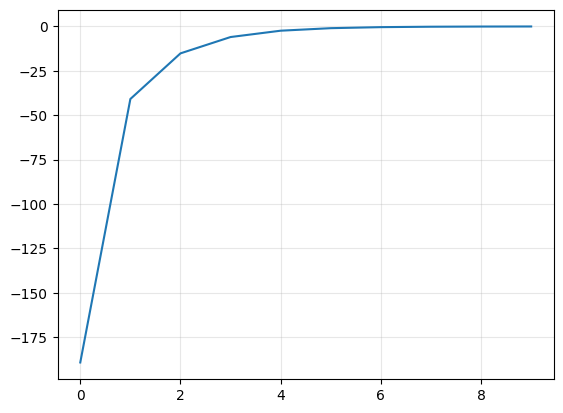

[  6.36861381   3.25537813  -9.20043747  25.45337182 -17.22005808
 -13.95261439   3.16937895]


In [121]:
clf = MyBinaryLogisticRegression(method='newton')
print(clf.fit(X, y).coefs_)

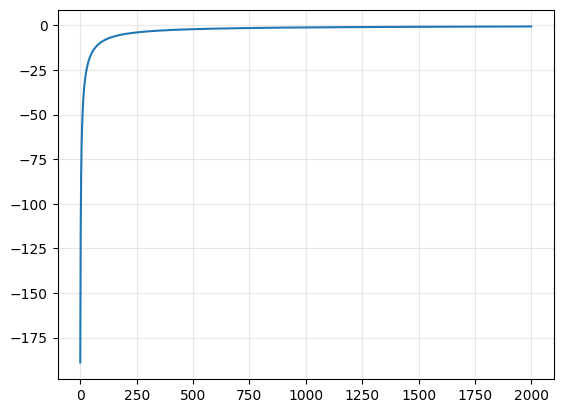

[ 3.28647122  4.54807278 -5.38339807 11.4866507  -8.50791791 -6.58715697
  1.59897801]


In [122]:
clf = MyBinaryLogisticRegression(method='gd')
print(clf.fit(X, y).coefs_)

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

**Решение:**

1. Найдем функцию потерь